# VP-SDE

--- Initializing VP-SDE ---
Model successfully loaded from checkpoint.


/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_19660/1541051575.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_

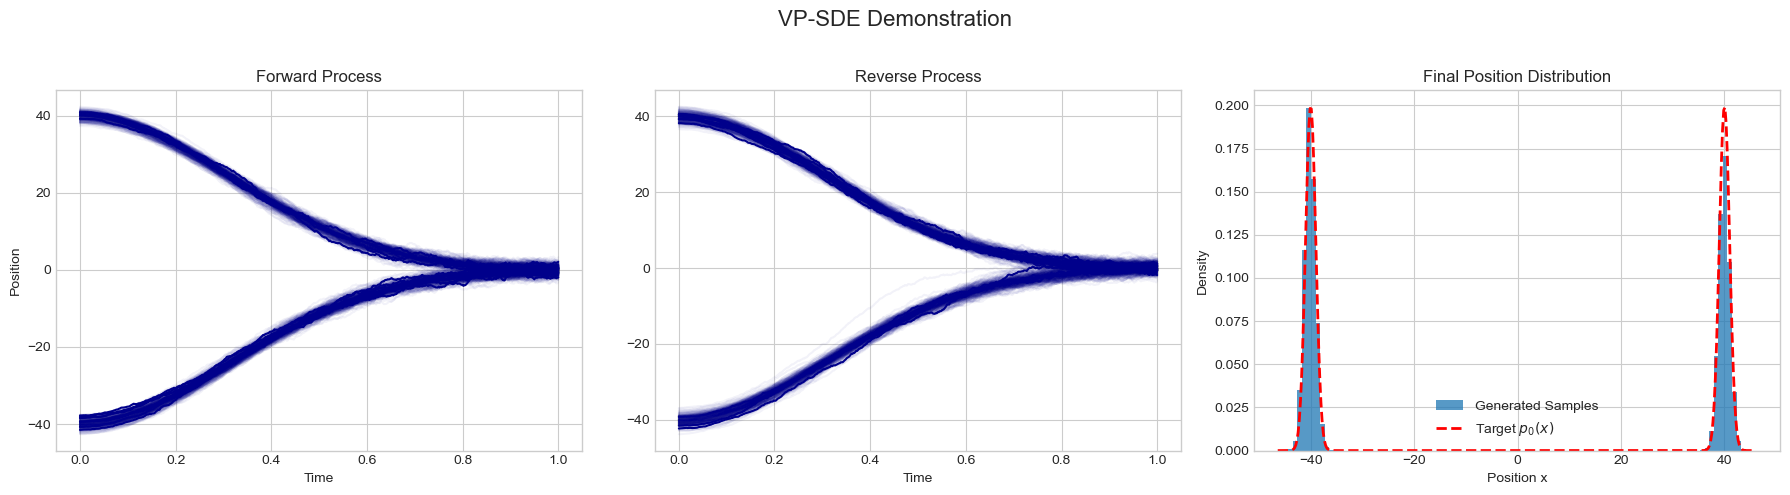

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from models import ScoreNetwork
from diffusion.vpsde import VPSDE
DEVICE = torch.device("cpu")  # or "cuda" if you trained on GPU

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-40., 40.],
    'stds': [1., 1.]
}
vpsde = VPSDE(GMM_PARAMS)

train = False
save_dir = "checkpoints/vpsde"
if train:
    # Train
    model, losses = vpsde.train_score_network_dsm(n_epochs=25, batch_size=128)

    # Save model
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, "score_net_final.pt"))

    # Save loss plot
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Score Network Training Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()


checkpoint_path = f"{save_dir}/score_net_final.pt"
model = ScoreNetwork().to(DEVICE)
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()
print("Model successfully loaded from checkpoint.")
n_plot, n_hist = 500, 10000
model.eval()
vpsde.run_demonstration(n_plot, n_hist, score_model=model)

# CLD

--- Initializing Critically Damped Langevin ---


/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_38827/1940479694.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_

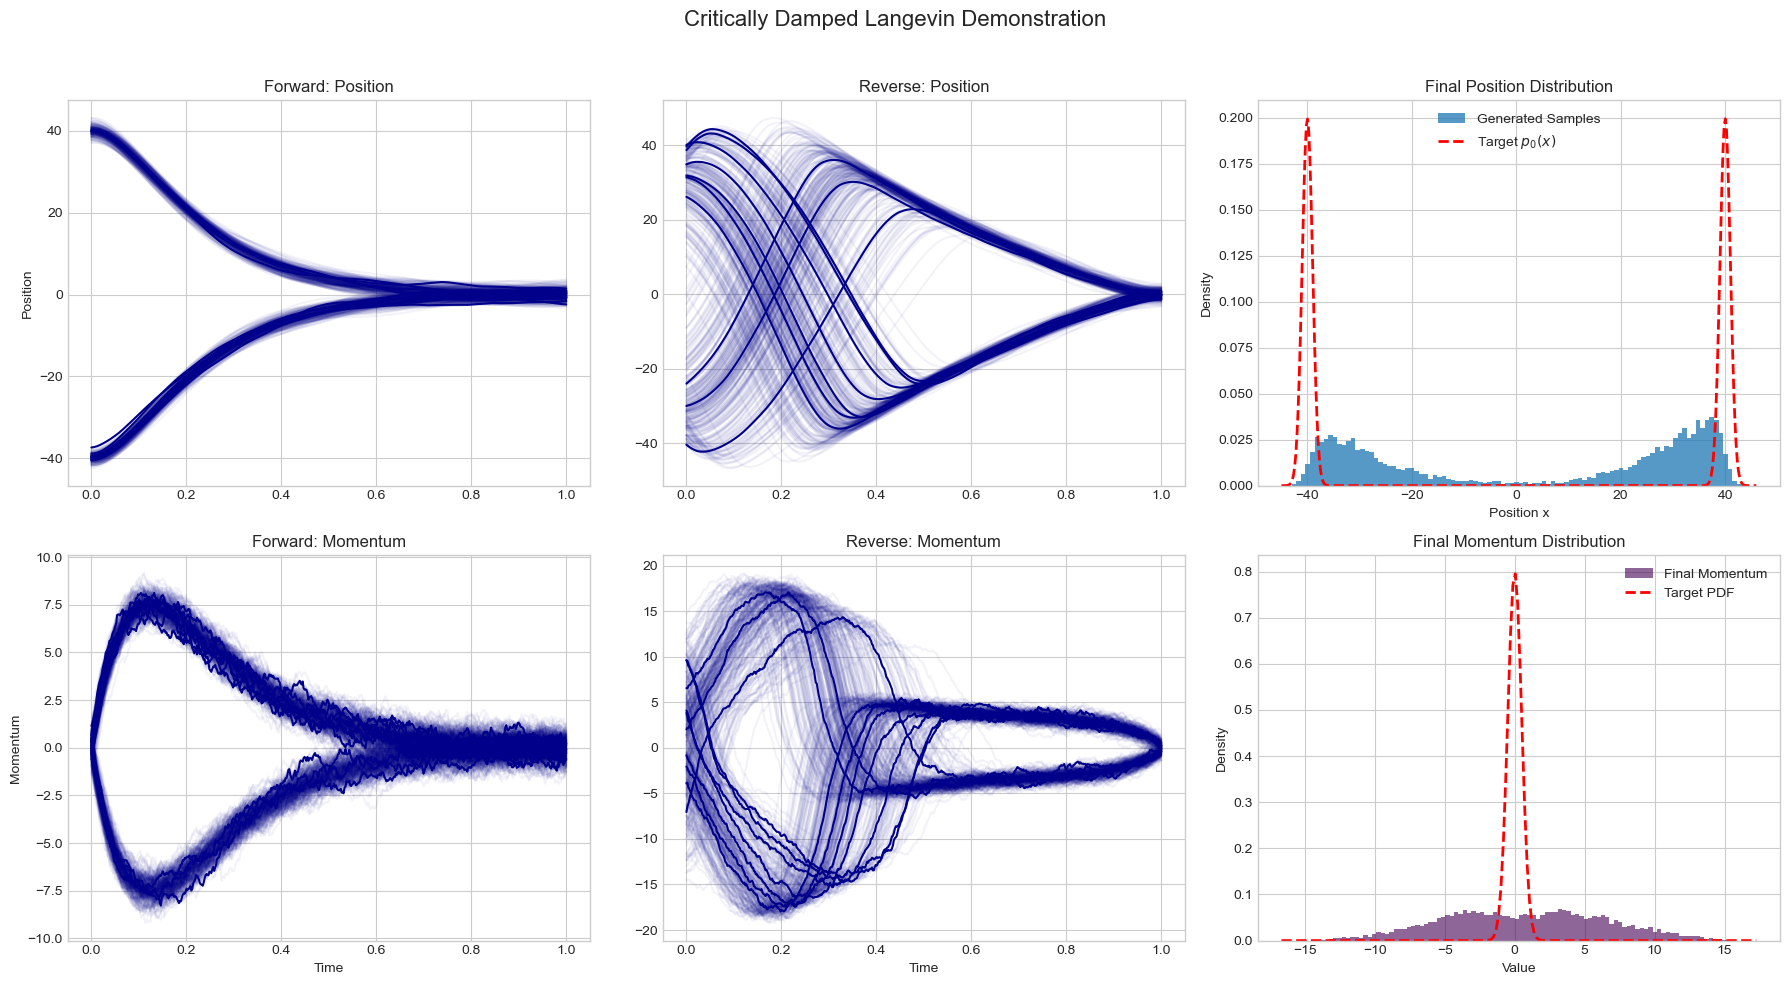

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from diffusion.cld import CriticallyDampedLangevin
from models import CLDScoreNetwork
DEVICE = torch.device("cpu")  # or "cuda" if you trained on GPU

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-40., 40.],
    'stds': [1., 1.]
}

# Initialize CLD
cld = CriticallyDampedLangevin(GMM_PARAMS)
save_dir = "checkpoints/cld"
train = False
if train:
    # Train with Hybrid Score Matching
    model, losses = cld.train_score_network_hsm(
        CLDScoreNetwork, n_epochs=25, batch_size=128, lr=1e-3
    )

    # Save model + training loss
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, "score_net_final.pt"))

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("CLD Hybrid Score Matching Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()

    print("Training complete. Model + loss plot saved in", save_dir)

checkpoint_path = f"{save_dir}/score_net_final.pt"
model = CLDScoreNetwork().to(DEVICE)
n_plot, n_hist = 500, 10000
model.eval()
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
cld.run_demonstration(n_plot, n_hist, score_model=model)  # Learned

# GLD

--- Initializing Generalized Langevin Diffusion ---
Checkpoint loaded successfully.


/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_19660/3669647075.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(chec

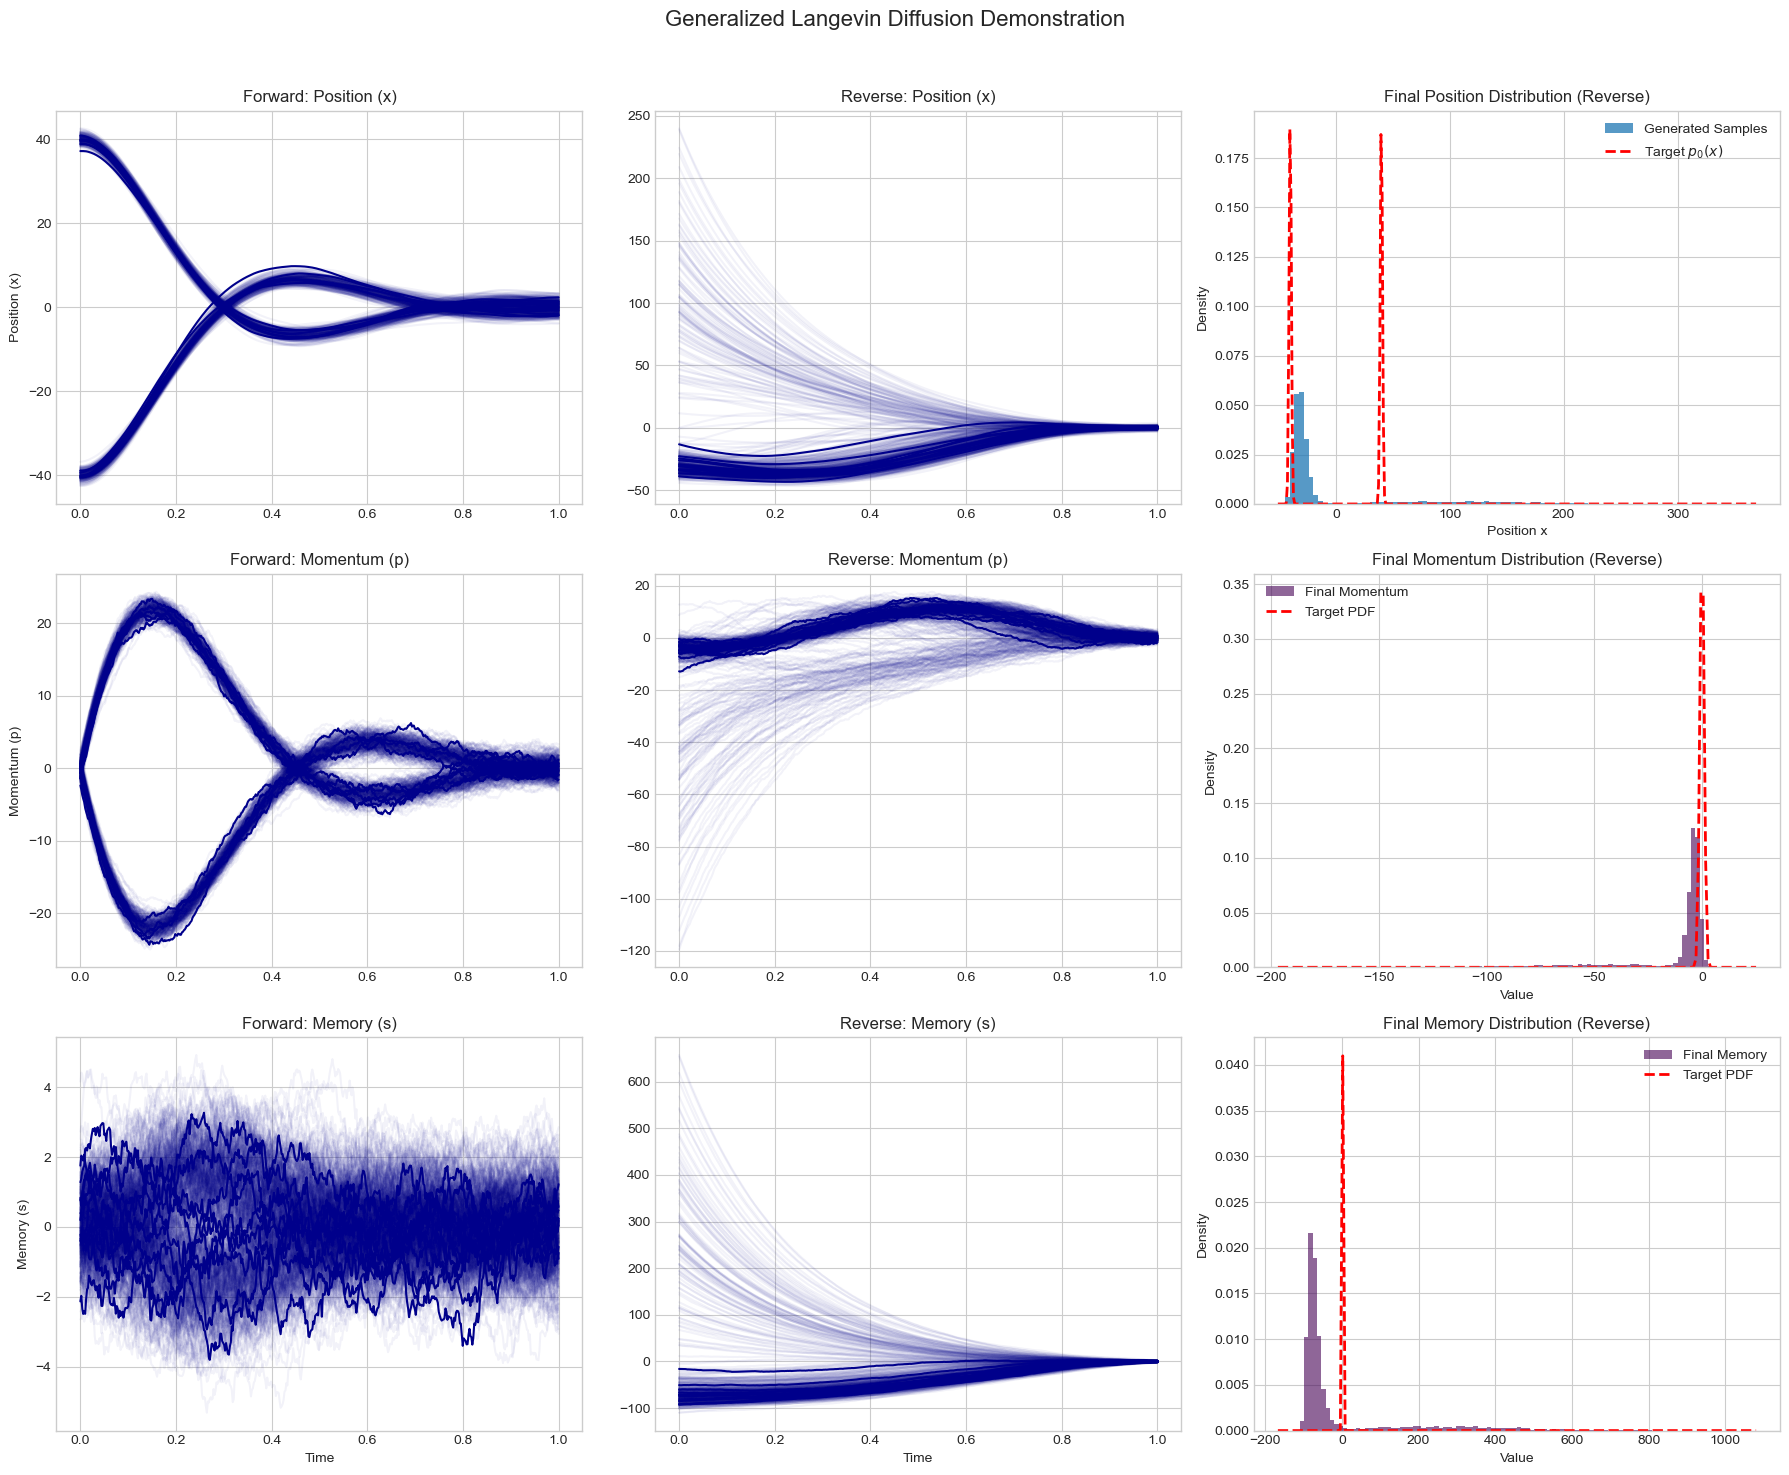

In [2]:
import os
import torch
import matplotlib.pyplot as plt
from diffusion.gld import GeneralizedLangevinDiffusion
from models import GLDScoreNetwork

# --- Define Gaussian Mixture Model (GMM) parameters ---
GMM_PARAMS = {
    "weights": [0.5, 0.5],
    "means": [-40., 40.],
    "stds": [1., 1.]
}
n_plot, n_hist = 500, 10000

# --- Initialize GLD ---
gld = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs', )
save_dir = "checkpoints/gld"
checkpoint_path = f"{save_dir}/score_net_final.pt"
train = False
if train:
    os.makedirs(save_dir, exist_ok=True)
    model, losses = gld.train_score_network_hsm(
        GLDScoreNetwork, n_epochs=25, batch_size=128, lr=1e-4
    )

    torch.save(model.state_dict(), checkpoint_path)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("GLD Hybrid Score Matching Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()

    print("Training complete. Model + loss plot saved in", save_dir)
    
loaded_model = GLDScoreNetwork()
loaded_model.load_state_dict(torch.load(checkpoint_path))
loaded_model.eval()

print("Checkpoint loaded successfully.")

_ = gld.run_demonstration(n_plot, n_hist, score_model=loaded_model)

/opt/anaconda3/lib/python3.11/site-packages/scipy/linalg/_solvers.py:193: RuntimeWarning: Input "a" has an eigenvalue pair whose sum is very close to or exactly zero. The solution is obtained via perturbing the coefficients.
  warnings.warn('Input "a" has an eigenvalue pair whose sum is '


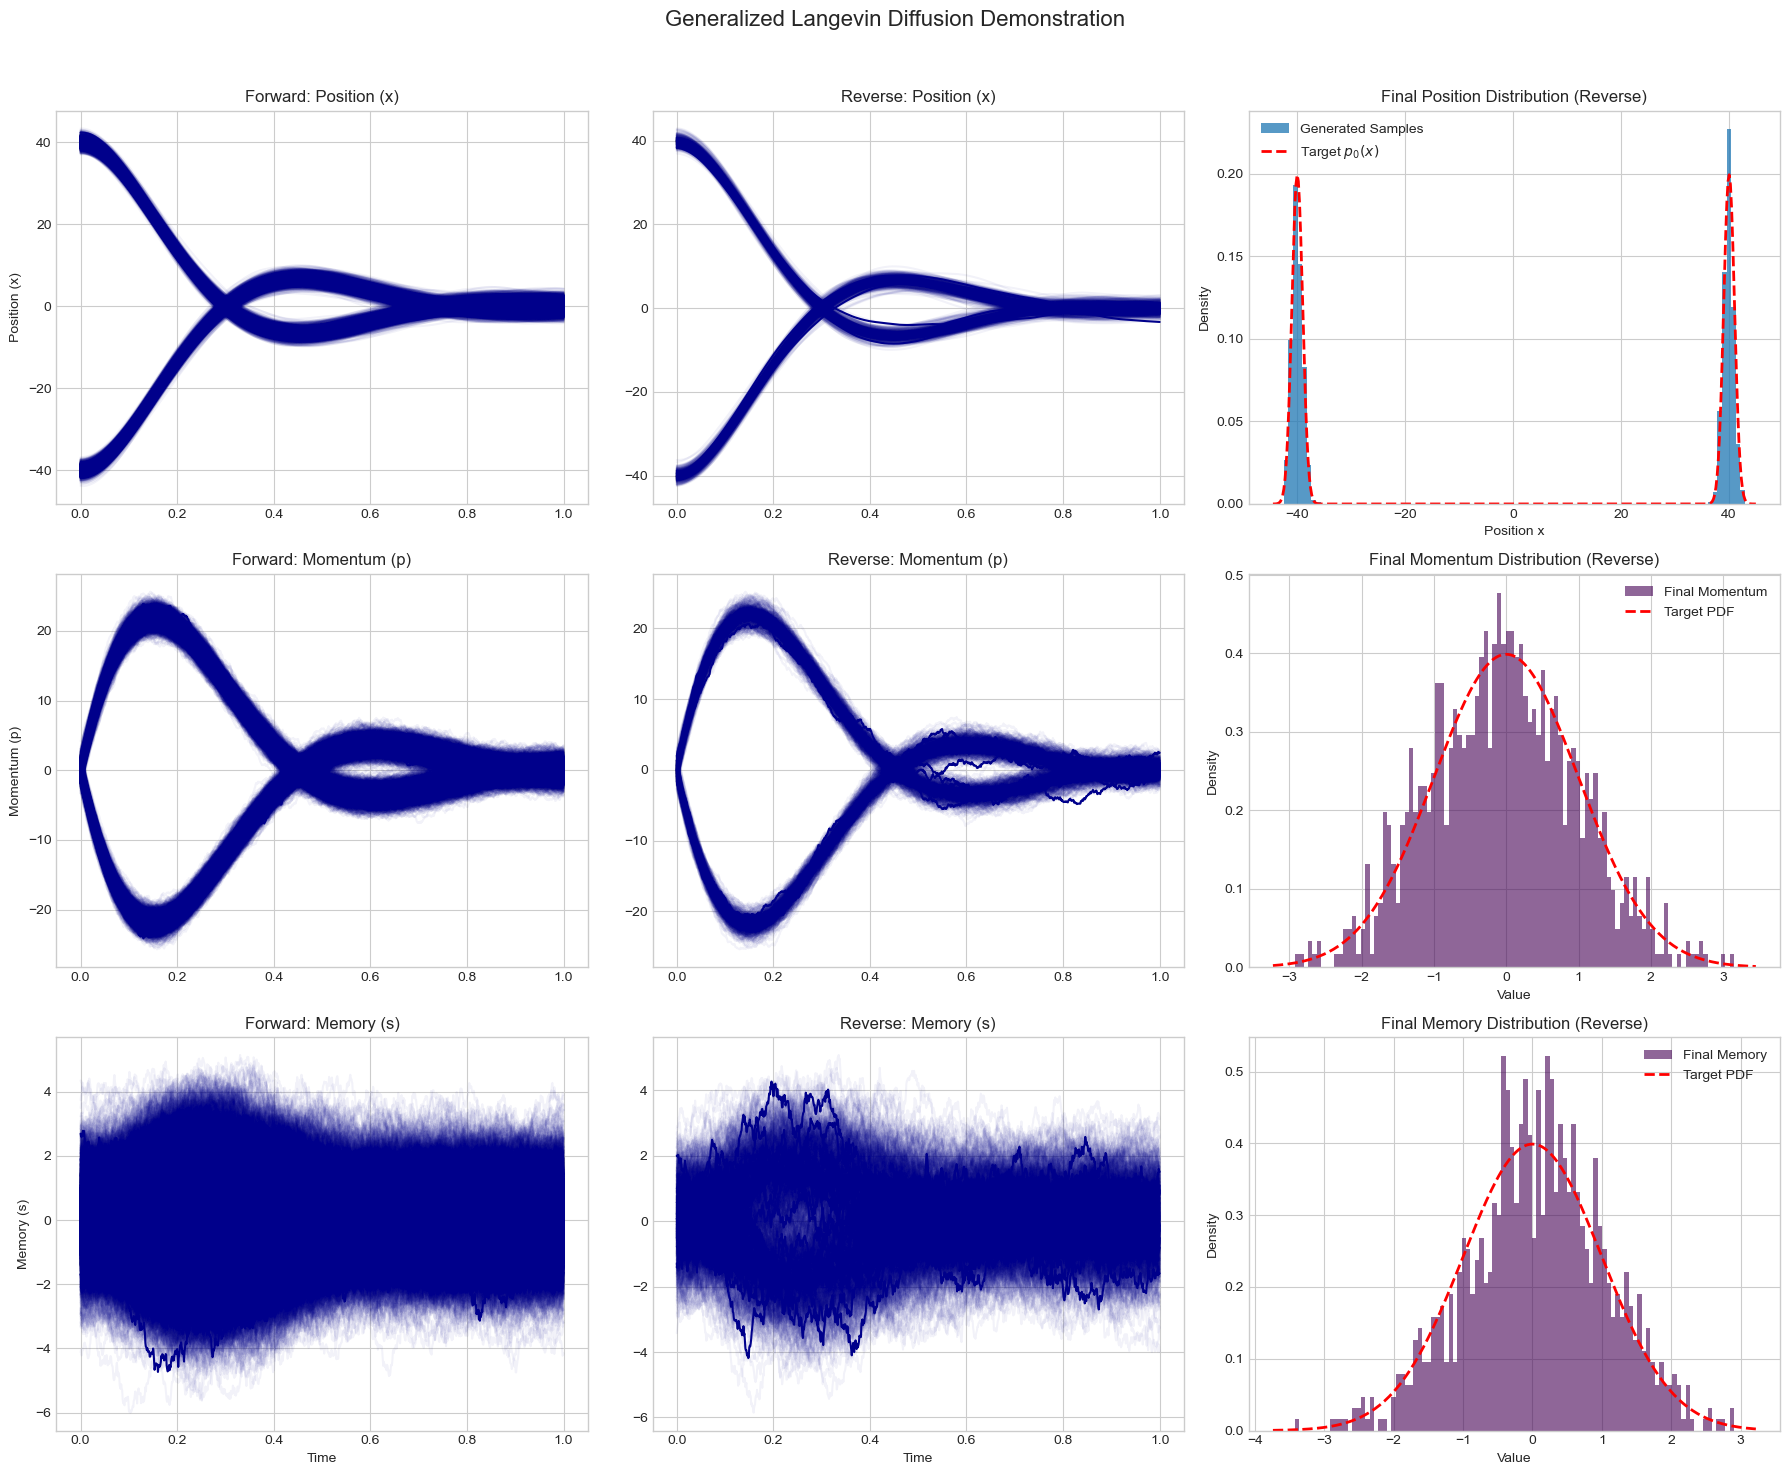

In [ ]:
# Check why momentum is flipped for single GMM mode.
n_plot, n_hist = 5000, 1000
_ = gld.run_demonstration(n_plot, n_hist, score_model=None)

--- Initializing Generalized Langevin Diffusion ---


/Users/rajit906/Downloads/PhD/PhD_Research/Current/GeneralizedLangevinDiffusion/gld/gmm/diffusion/gld.py:540: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weights_tensor = torch.tensor(self.gmm_params['weights'], device=device, dtype=torch.float32)


[GLD HSM] Epoch 1/25 - Loss: 0.742458
[GLD HSM] Epoch 2/25 - Loss: 0.468944
[GLD HSM] Epoch 3/25 - Loss: 0.255826
[GLD HSM] Epoch 4/25 - Loss: 0.118046
[GLD HSM] Epoch 5/25 - Loss: 0.072550
[GLD HSM] Epoch 6/25 - Loss: 0.055454
[GLD HSM] Epoch 7/25 - Loss: 0.047227
[GLD HSM] Epoch 8/25 - Loss: 0.040326
[GLD HSM] Epoch 9/25 - Loss: 0.044157
[GLD HSM] Epoch 10/25 - Loss: 0.030415
[GLD HSM] Epoch 11/25 - Loss: 0.041665
[GLD HSM] Epoch 12/25 - Loss: 0.030785
[GLD HSM] Epoch 13/25 - Loss: 0.032438
[GLD HSM] Epoch 14/25 - Loss: 0.030275
[GLD HSM] Epoch 15/25 - Loss: 0.029623
[GLD HSM] Epoch 16/25 - Loss: 0.031828
[GLD HSM] Epoch 17/25 - Loss: 0.026929
[GLD HSM] Epoch 18/25 - Loss: 0.024618
[GLD HSM] Epoch 19/25 - Loss: 0.026467
[GLD HSM] Epoch 20/25 - Loss: 0.022509
[GLD HSM] Epoch 21/25 - Loss: 0.029185
[GLD HSM] Epoch 22/25 - Loss: 0.021735
[GLD HSM] Epoch 23/25 - Loss: 0.024177
[GLD HSM] Epoch 24/25 - Loss: 0.023094
[GLD HSM] Epoch 25/25 - Loss: 0.020778
Training complete. Model + loss pl

/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_37871/3999748457.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(chec

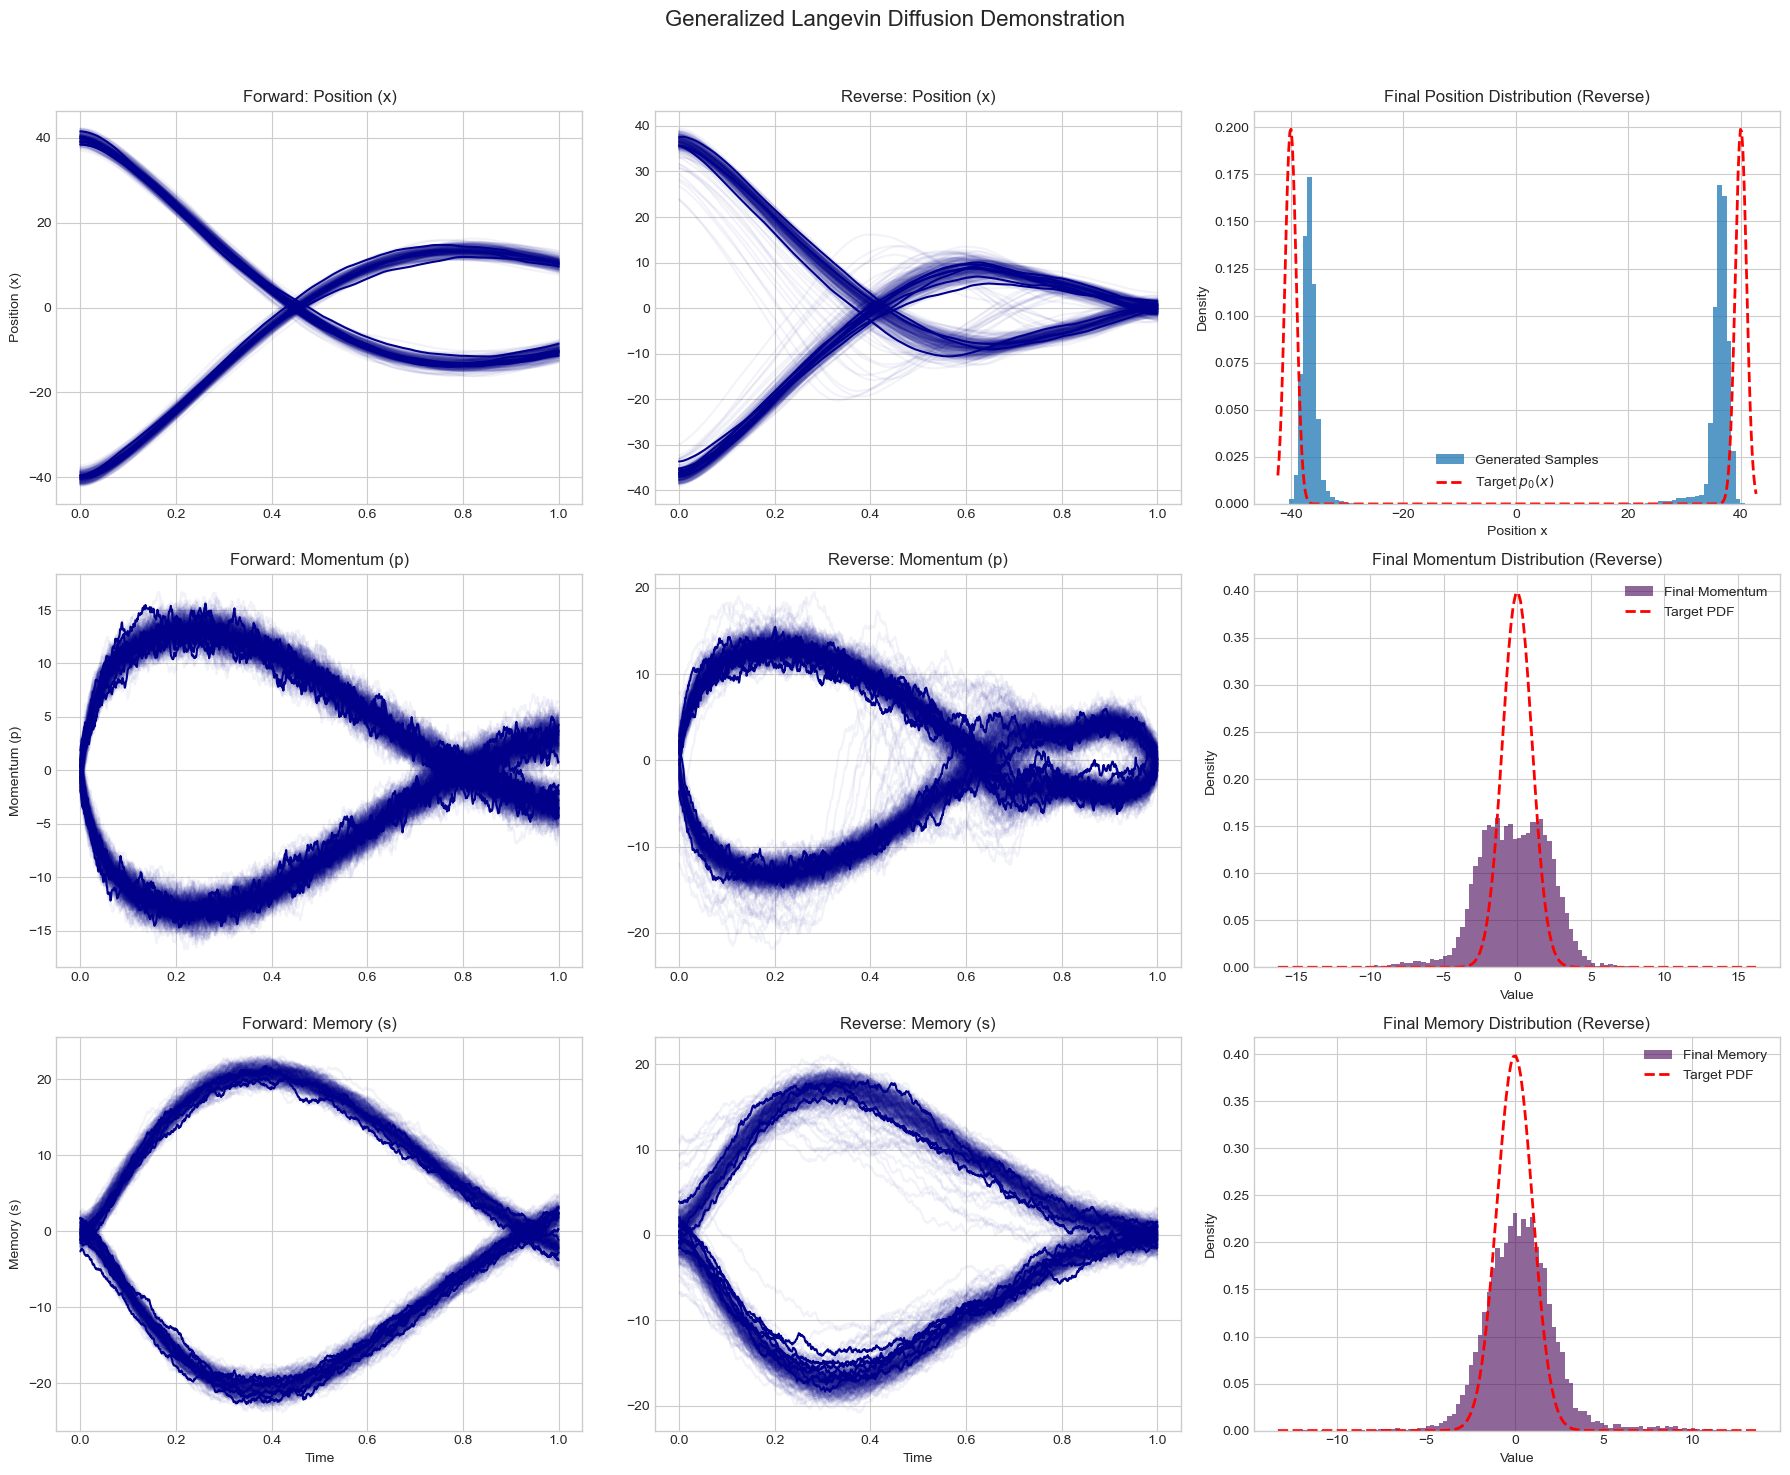

In [1]:
# Increase beta to 24 * sqrt(M) here.
import os
import torch
import matplotlib.pyplot as plt
from diffusion.gld import GeneralizedLangevinDiffusion
from models import GLDScoreNetwork

# --- Define Gaussian Mixture Model (GMM) parameters ---
GMM_PARAMS = {
    "weights": [0.5, 0.5],
    "means": [-40., 40.],
    "stds": [1., 1.]
}
n_plot, n_hist = 500, 10000

# --- Initialize GLD ---
gld = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs2', gamma=2., lambda_val=1., c_val=0.9, M=1., n_steps=1000)
save_dir = "checkpoints/gld"
checkpoint_path = f"{save_dir}/score_net_final.pt"
train = True
if train:
    os.makedirs(save_dir, exist_ok=True)
    model, losses = gld.train_score_network_hsm(
        GLDScoreNetwork, n_epochs=25, batch_size=128, lr=1e-4
    )

    torch.save(model.state_dict(), checkpoint_path)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("GLD Hybrid Score Matching Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()

    print("Training complete. Model + loss plot saved in", save_dir)
    
loaded_model = GLDScoreNetwork()
loaded_model.load_state_dict(torch.load(checkpoint_path))
loaded_model.eval()

print("Checkpoint loaded successfully.")

_ = gld.run_demonstration(n_plot, n_hist, score_model=loaded_model)

--- Initializing Generalized Langevin Diffusion ---


/Users/rajit906/Downloads/PhD/PhD_Research/Current/GeneralizedLangevinDiffusion/gld/gmm/diffusion/gld.py:540: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weights_tensor = torch.tensor(self.gmm_params['weights'], device=device, dtype=torch.float32)


[GLD HSM] Epoch 1/25 - Loss: 0.277346
[GLD HSM] Epoch 2/25 - Loss: 0.075461
[GLD HSM] Epoch 3/25 - Loss: 0.057865
[GLD HSM] Epoch 4/25 - Loss: 0.050107
[GLD HSM] Epoch 5/25 - Loss: 0.044509
[GLD HSM] Epoch 6/25 - Loss: 0.043179
[GLD HSM] Epoch 7/25 - Loss: 0.038589
[GLD HSM] Epoch 8/25 - Loss: 0.036061
[GLD HSM] Epoch 9/25 - Loss: 0.035516
[GLD HSM] Epoch 10/25 - Loss: 0.028693
[GLD HSM] Epoch 11/25 - Loss: 0.035823
[GLD HSM] Epoch 12/25 - Loss: 0.028026
[GLD HSM] Epoch 13/25 - Loss: 0.028413
[GLD HSM] Epoch 14/25 - Loss: 0.031129
[GLD HSM] Epoch 15/25 - Loss: 0.026023
[GLD HSM] Epoch 16/25 - Loss: 0.028375
[GLD HSM] Epoch 17/25 - Loss: 0.028096
[GLD HSM] Epoch 18/25 - Loss: 0.023155
[GLD HSM] Epoch 19/25 - Loss: 0.025629
[GLD HSM] Epoch 20/25 - Loss: 0.026030
[GLD HSM] Epoch 21/25 - Loss: 0.021869
[GLD HSM] Epoch 22/25 - Loss: 0.024561
[GLD HSM] Epoch 23/25 - Loss: 0.023071
[GLD HSM] Epoch 24/25 - Loss: 0.021311
[GLD HSM] Epoch 25/25 - Loss: 0.018542
Training complete. Model + loss pl

/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_38105/3999748457.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(chec

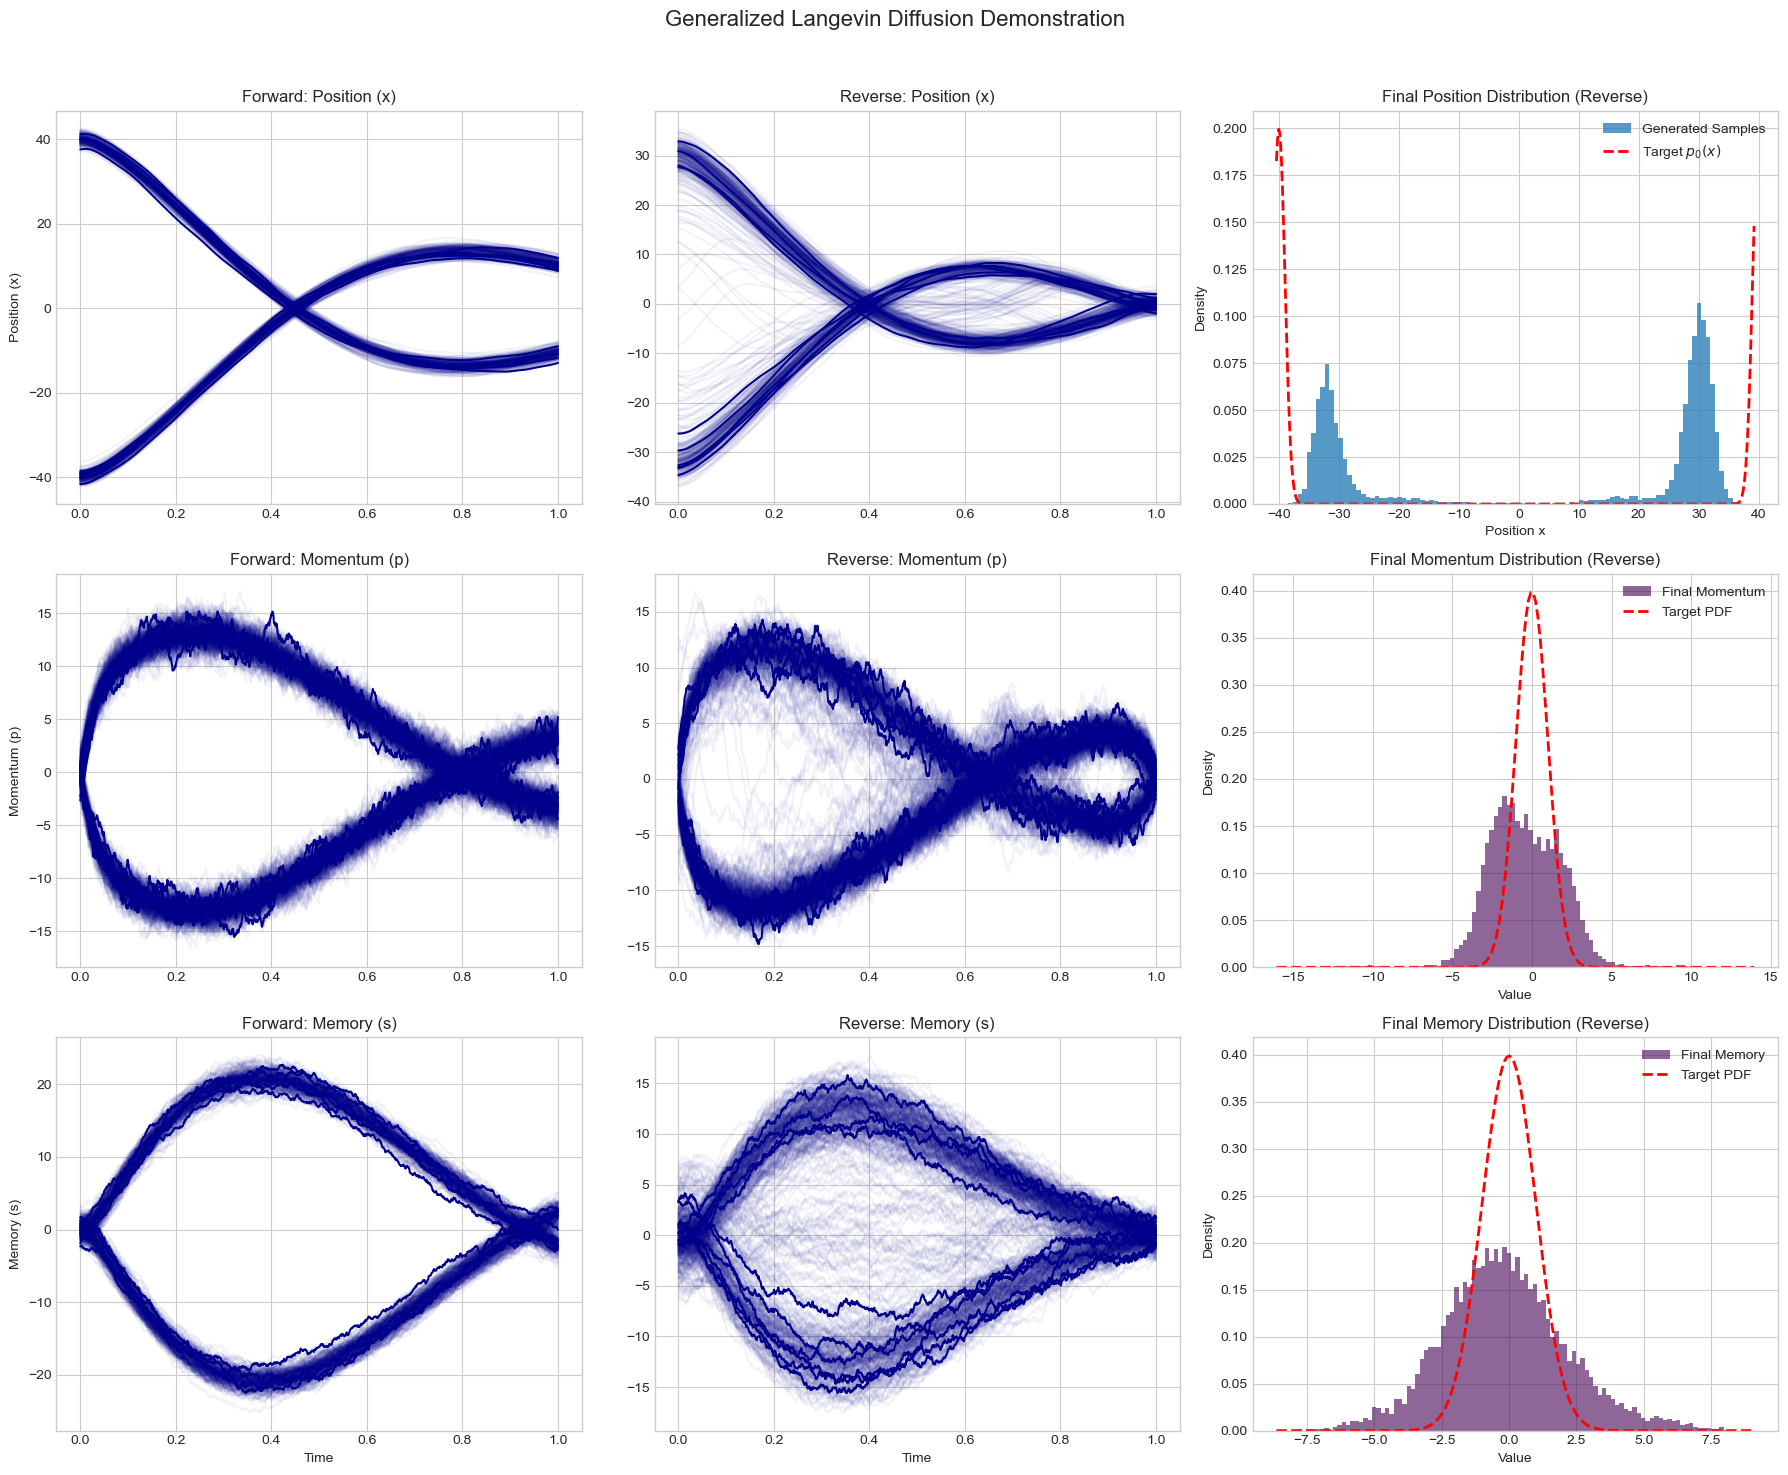

In [1]:
# Increase beta to 24 * sqrt(M) here.
import os
import torch
import matplotlib.pyplot as plt
from diffusion.gld import GeneralizedLangevinDiffusion
from models import GLDScoreNetwork

# --- Define Gaussian Mixture Model (GMM) parameters ---
GMM_PARAMS = {
    "weights": [0.5, 0.5],
    "means": [-40., 40.],
    "stds": [1., 1.]
}
n_plot, n_hist = 500, 10000

# --- Initialize GLD ---
gld = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs2', gamma=2., lambda_val=1., c_val=0.9, M=1., n_steps=1000)
save_dir = "checkpoints/gld"
checkpoint_path = f"{save_dir}/score_net_final.pt"
train = True
if train:
    os.makedirs(save_dir, exist_ok=True)
    model, losses = gld.train_score_network_hsm(
        GLDScoreNetwork, n_epochs=25, batch_size=128, lr=1e-4
    )

    torch.save(model.state_dict(), checkpoint_path)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("GLD Hybrid Score Matching Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()

    print("Training complete. Model + loss plot saved in", save_dir)
    
loaded_model = GLDScoreNetwork()
loaded_model.load_state_dict(torch.load(checkpoint_path))
loaded_model.eval()

print("Checkpoint loaded successfully.")

_ = gld.run_demonstration(n_plot, n_hist, score_model=loaded_model)